# GARCH Stock Forecasting

## Read Data

In [10]:
import pandas_datareader.data as web
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np
from curl_cffi import requests
import yfinance as yf

In [9]:
session = requests.Session(impersonate='chrome')

## DIS Volatility

In [2]:
start = datetime(2015, 1, 1)
end = datetime(2020, 6, 10)

In [11]:
dis = yf.download('^GSPC', start, end, session = session)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [12]:
returns = 100 * dis.Close.pct_change().dropna()

Text(0.5, 1.0, 'DIS Returns')

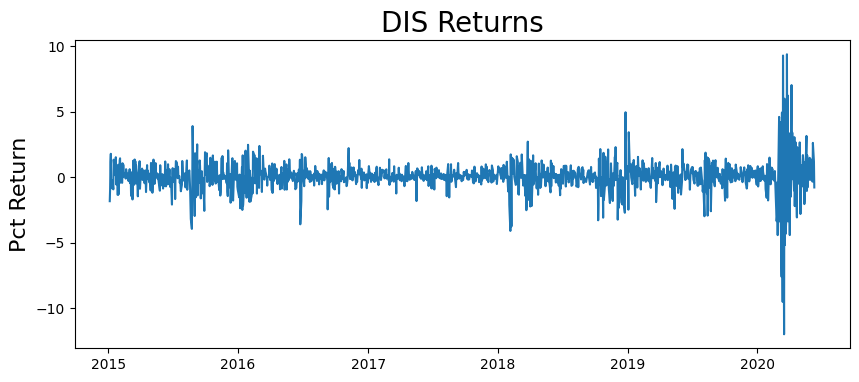

In [13]:
plt.figure(figsize=(10,4))
plt.plot(returns)
plt.ylabel('Pct Return', fontsize=16)
plt.title('DIS Returns', fontsize=20)

## PACF

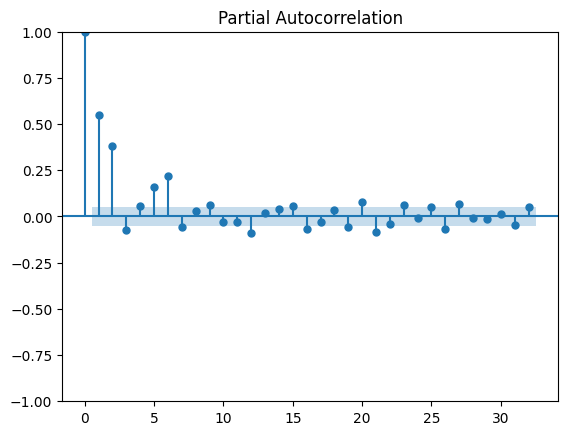

In [14]:
plot_pacf(returns**2)
plt.show()

## Fit GARCH(3,3)

In [15]:
model = arch_model(returns, p=3, q=3)

In [17]:
model_fit = model.fit(disp='off')

In [18]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1613.44
Distribution:                  Normal   AIC:                           3242.88
Method:            Maximum Likelihood   BIC:                           3284.64
                                        No. Observations:                 1367
Date:                Mon, May 12 2025   Df Residuals:                     1366
Time:                        16:33:24   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0908  2.189e-02      4.149  3.340e-05 [4.792e-02,  0.134]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.0925  7.981e-02      1.160      0.246 [-6.388e-02,  0.249]
alpha[1]       0.2602      0.178      1.461      0.144 [-8.879e-02,  0.609]
alpha[2]       0.1097      0.787      0.139      0.889    [ -1.433,  1.652]
alpha[3]       0.1671      0.489      0.342      0.732    [ -0.791,  1.125]
beta[1]    2.2299e-15      3.124  7.138e-16      1.000    [ -6.123,  6.123]
beta[2]        0.0000      1.393      0.000      1.000    [ -2.730,  2.730]
beta[3]        0.3886      1.198      0.324      0.746    [ -1.959,  2.736]
===========================================================================

Covariance estimator: robust
"""

## Try GARCH(3,0) = ARCH(3)

In [29]:
model = arch_model(returns, p=3, q=0)

In [30]:
model_fit = model.fit(disp='off')

In [31]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -1660.35
Distribution:                  Normal   AIC:                           3330.70
Method:            Maximum Likelihood   BIC:                           3356.80
                                        No. Observations:                 1367
Date:                Mon, May 12 2025   Df Residuals:                     1366
Time:                        16:36:15   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0897  1.871e-02      4.796  1.622e-06 [5.305e-02,  0.126]
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          0.2435  3.445e-02      7.067  1.578e-12 [  0.176,  0.311]
alpha[1]       0.2914  6.477e-02      4.499  6.828e-06 [  0.164,  0.418]
alpha[2]       0.2531  5.369e-02      4.714  2.425e-06 [  0.148,  0.358]
alpha[3]       0.2818  6.129e-02      4.598  4.275e-06 [  0.162,  0.402]
========================================================================

Covariance estimator: robust
"""

In [32]:
rolling_predictions = []
test_size = 365

for i in range(test_size):
    train = returns[:-(test_size-i)]
    model = arch_model(train, p=3, q=0)
    model_fit = model.fit(disp='off')
    pred = model_fit.forecast(horizon=1)
    rolling_predictions.append(np.sqrt(pred.variance.values[-1,:][0]))

In [20]:
rolling_predictions = pd.Series(rolling_predictions, index=returns.index[-365:])

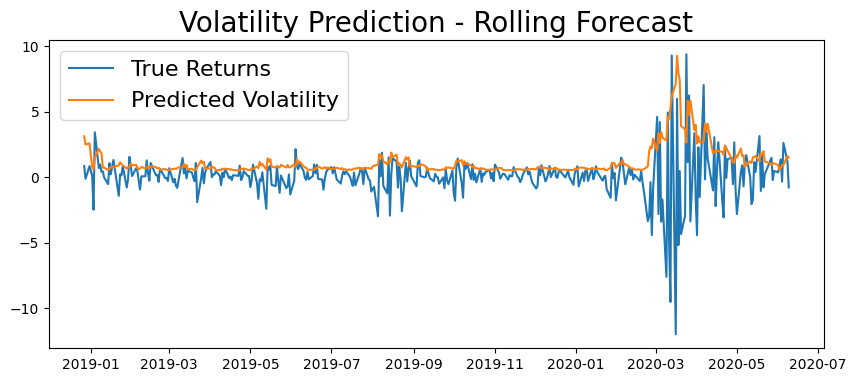

In [21]:
plt.figure(figsize=(10,4))
true, = plt.plot(returns[-365:])
preds, = plt.plot(rolling_predictions)
plt.title('Volatility Prediction - Rolling Forecast', fontsize=20)
plt.legend(['True Returns', 'Predicted Volatility'], fontsize=16)

# S&P 500

In [ ]:
start = datetime(2000, 1, 1)
end = datetime(2020, 6, 10)

In [ ]:
spy = web.DataReader('SPY', 'yahoo', start=start, end=end)

In [ ]:
returns = 100 * spy.Close.pct_change().dropna()

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(returns)
plt.ylabel('Pct Return', fontsize=16)
plt.title('SPY Returns', fontsize=20)

## PACF

In [ ]:
plot_pacf(returns**2)
plt.show()

## Fit GARCH(2,2)

In [ ]:
model = arch_model(returns, p=2, q=2)

In [ ]:
model_fit = model.fit()

In [ ]:
model_fit.summary()

## Rolling Forecast

In [ ]:
rolling_predictions = []
test_size = 365*5

for i in range(test_size):
    train = returns[:-(test_size-i)]
    model = arch_model(train, p=2, q=2)
    model_fit = model.fit(disp='off')
    pred = model_fit.forecast(horizon=1)
    rolling_predictions.append(np.sqrt(pred.variance.values[-1,:][0]))

In [ ]:
rolling_predictions = pd.Series(rolling_predictions, index=returns.index[-365*5:])

In [ ]:
plt.figure(figsize=(10,4))
true, = plt.plot(returns[-365*5:])
preds, = plt.plot(rolling_predictions)
plt.title('Volatility Prediction - Rolling Forecast', fontsize=20)
plt.legend(['True Returns', 'Predicted Volatility'], fontsize=16)

# How to use the model

In [22]:
train = returns
model = arch_model(train, p=2, q=2)
model_fit = model.fit(disp='off')

In [23]:
pred = model_fit.forecast(horizon=7)
future_dates = [returns.index[-1] + timedelta(days=i) for i in range(1,8)]
pred = pd.Series(np.sqrt(pred.variance.values[-1,:]), index=future_dates)

Text(0.5, 1.0, 'Volatility Prediction - Next 7 Days')

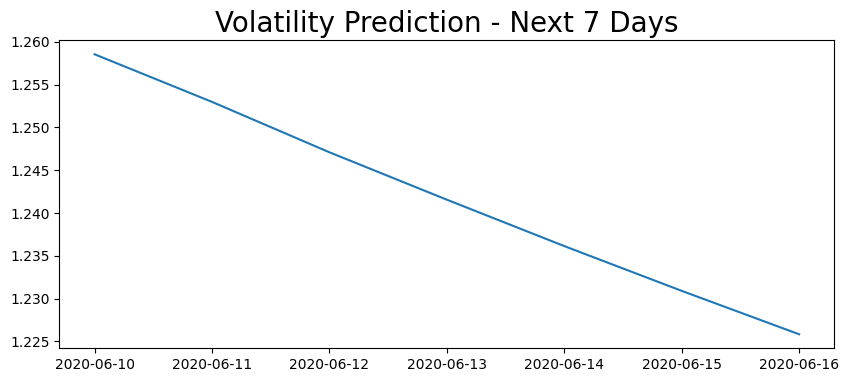

In [24]:
plt.figure(figsize=(10,4))
plt.plot(pred)
plt.title('Volatility Prediction - Next 7 Days', fontsize=20)